# ✅ Test Accuracy: 64.55% CNN+Yolo

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Image settings
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Directories
train_dir = 'dataset/train'
val_dir = 'dataset/val'
test_dir = 'dataset/test'  # Add a test set for evaluation

# Data generators
train_gen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, zoom_range=0.2)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

val_data = val_gen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

test_data = test_gen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=1, class_mode='categorical', shuffle=False)

# Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(*IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(train_data, validation_data=val_data, epochs=15)

# Save model
model.save('activity_classifier_03.h5')
print("✅ Activity Classifier Saved!")

# -------------------------------
# 📊 Evaluation on Test Data
# -------------------------------

# Predict
pred_probs = model.predict(test_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Accuracy
test_acc = np.sum(pred_classes == true_classes) / len(true_classes)
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

# Classification report
print("\n📄 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('🧩 Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()


# Upgraded version

Found 333 images belonging to 9 classes.
Found 98 images belonging to 9 classes.
Found 110 images belonging to 9 classes.


c:\Users\Madye\Desktop\TimeSeriesAnomalyDetection\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,519,241 (24.87 MB)

...

c:\Users\Madye\Desktop\TimeSeriesAnomalyDetection\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.3319 - loss: 7.3363

11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 962ms/step - accuracy: 0.3323 - loss: 7.3668 - val_accuracy: 0.2347 - val_loss: 2.0329 - learning_rate: 0.0010
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 808ms/step - accuracy: 0.4420 - loss: 3.7913 - val_accuracy: 0.1429 - val_loss: 5.1346 - learning_rate: 0.0010
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 936ms/step - accuracy: 0.4374 - loss: 3.1290 - val_accuracy: 0.1531 - val_loss: 9.0605 - learning_rate: 0.0010
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 978ms/step - accuracy: 0.5162 - loss: 1.9699
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5143 - loss: 1.9832 - val_accuracy: 0.1531 - val_loss: 15.3476 - learning_rate: 0.0010
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5569 - loss: 1.7480 - val_accuracy: 0.1327 - val_loss: 20.2646 - learning_rate: 2.0000e-04
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6355 - loss: 1.4953 - val_accur

✅ Model saved as activity_classifier_improved.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

✅ Test Accuracy: 24.55%

📄 Classification Report:
                    precision    recall  f1-score   support

          exercise       0.00      0.00      0.00         9
              fall       0.27      0.50      0.35        18
             lying       0.00      0.00      0.00         9
               run       0.00      0.00      0.00        13
               sit       1.00      0.35      0.52        17
             stand       0.20      0.08      0.11        13
              walk       0.10      0.06      0.07        17
walking_downstairs       0.16      1.00      0.28         9
  walking_upstairs       1.00      0.20      0.33         5

          accuracy                           0.25       110
         macro avg       0.30      0.24      0.19       110
      weighted avg       0.30      0.25      0.20       110



c:\Users\Madye\Desktop\TimeSeriesAnomalyDetection\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Madye\Desktop\TimeSeriesAnomalyDetection\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Madye\Desktop\TimeSeriesAnomalyDetection\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

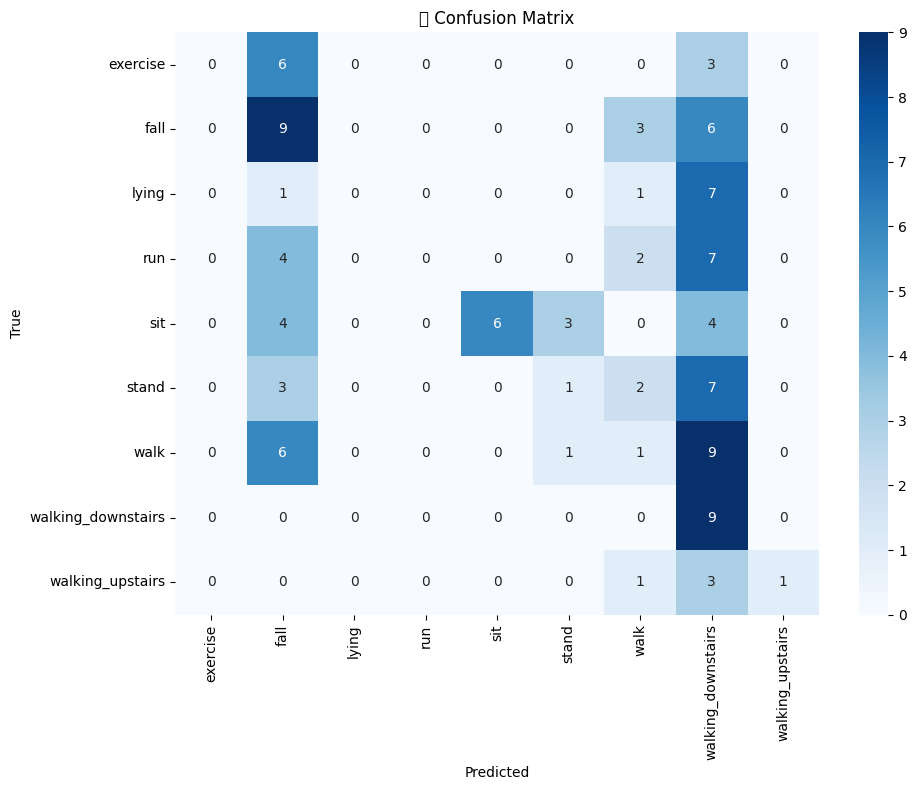

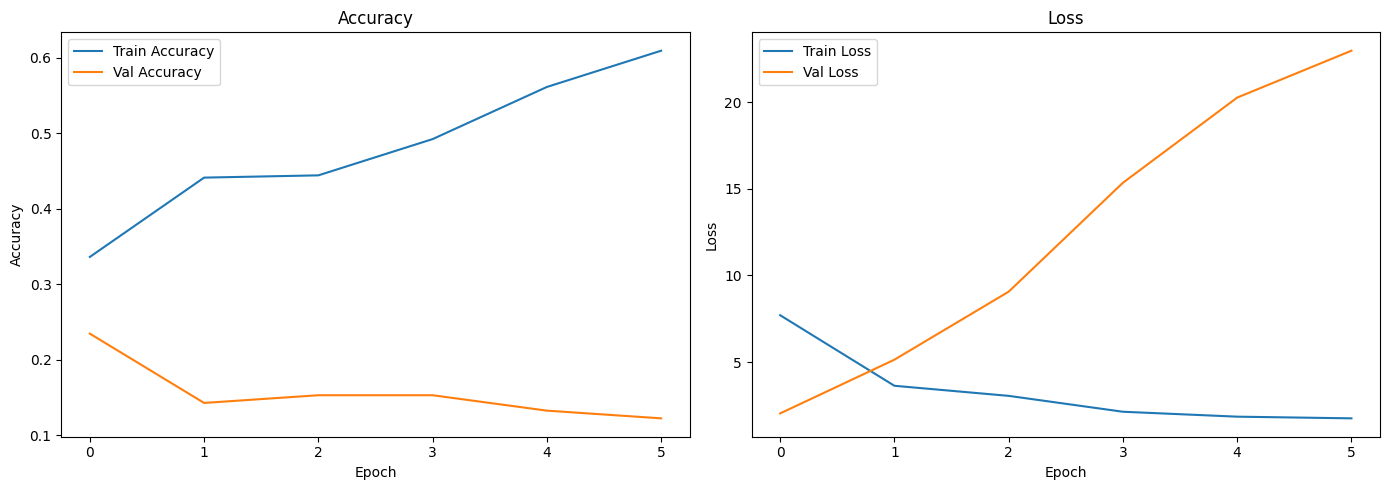

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# -------------------------------
# ⚙️ Configuration
# -------------------------------
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30

train_dir = 'dataset/train'
val_dir = 'dataset/val'
test_dir = 'dataset/test'
MODEL_NAME = 'activity_classifier_improved.h5'

# -------------------------------
# 🔁 Data Preprocessing
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

val_data = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

test_data = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=1, class_mode='categorical', shuffle=False)

# -------------------------------
# 🧠 Model Architecture
# -------------------------------
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(*IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# -------------------------------
# 📉 Callbacks
# -------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
    ModelCheckpoint(MODEL_NAME, save_best_only=True)
]

# -------------------------------
# 🚀 Train Model
# -------------------------------
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
)

# -------------------------------
# 💾 Save Model
# -------------------------------
model.save(MODEL_NAME)
print(f"✅ Model saved as {MODEL_NAME}")

# -------------------------------
# 📊 Evaluation on Test Data
# -------------------------------
pred_probs = model.predict(test_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

test_acc = np.mean(pred_classes == true_classes)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# 🧾 Classification Report
print("\n📄 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# 🔍 Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('🧩 Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_04.png')
plt.show()

# -------------------------------
# 📈 Plot Accuracy and Loss
# -------------------------------
def plot_history(hist):
    plt.figure(figsize=(14, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label='Train Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.show()

plot_history(history)


In [4]:
# Check class distribution
import os
from collections import Counter

root = 'dataset'  # each class in its own folder
class_counts = Counter()

for class_name in os.listdir(root):
    class_path = os.path.join(root, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[class_name] = count

print(class_counts)


Counter({'test': 9, 'train': 9, 'val': 9})


# ResNet for Activity Classifier

Found 333 images belonging to 9 classes.
Found 98 images belonging to 9 classes.
Found 110 images belonging to 9 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,569 (91.99 MB)

 Trainable params: 526,857 (2.01 MB)

...

11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.1655 - loss: 2.3026 - val_accuracy: 0.1633 - val_loss: 2.1764 - learning_rate: 0.0010
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1829 - loss: 2.2205

11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.1827 - loss: 2.2215 - val_accuracy: 0.1633 - val_loss: 2.1579 - learning_rate: 0.0010
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1985 - loss: 2.1722

11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.1972 - loss: 2.1709 - val_accuracy: 0.2653 - val_loss: 2.1294 - learning_rate: 0.0010
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.1693 - loss: 2.1565 - val_accuracy: 0.1633 - val_loss: 2.1343 - learning_rate: 0.0010
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.1687 - loss: 2.1708 - val_accuracy: 0.1837 - val_loss: 2.1479 - learning_rate: 0.0010
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1818 - loss: 2.1550
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.1796 - loss: 2.1543 - val_accuracy: 0.2449 - val_loss: 2.1447 - learning_rate: 0.0010
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.1974 - loss: 2.1321 - val_accuracy: 0.2449 - val_loss: 2.1418 - learning_rate: 2.0000e-04
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.1992 - loss: 2.1160 - val_accuracy: 0.1735

✅ Model saved as activity_classifier_resnet50.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step

✅ Test Accuracy: 25.45%

📄 Classification Report:
                    precision    recall  f1-score   support

          exercise       0.00      0.00      0.00         9
              fall       0.00      0.00      0.00        18
             lying       0.00      0.00      0.00         9
               run       0.00      0.00      0.00        13
               sit       0.56      0.53      0.55        17
             stand       0.22      0.62      0.33        13
              walk       0.19      0.65      0.29        17
walking_downstairs       0.00      0.00      0.00         9
  walking_upstairs       0.00      0.00      0.00         5

          accuracy                           0.25       110
         macro avg       0.11      0.20      0.13       110
      weighted avg       0.14      0.25      0.17       110



c:\Users\Madye\Desktop\TimeSeriesAnomalyDetection\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Madye\Desktop\TimeSeriesAnomalyDetection\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Madye\Desktop\TimeSeriesAnomalyDetection\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

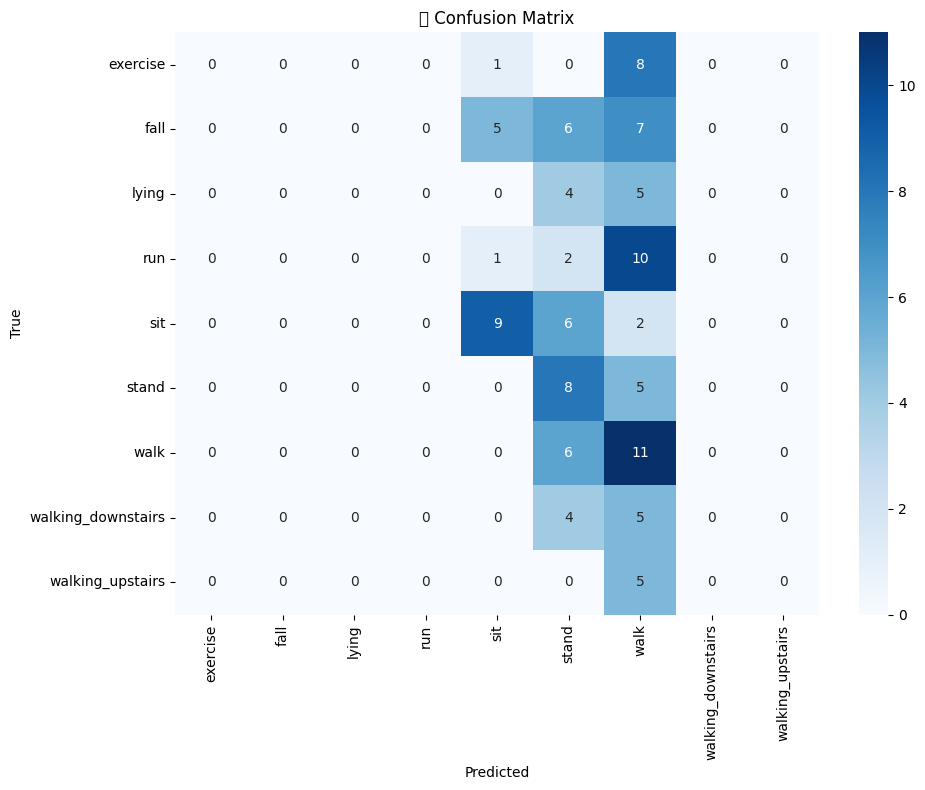

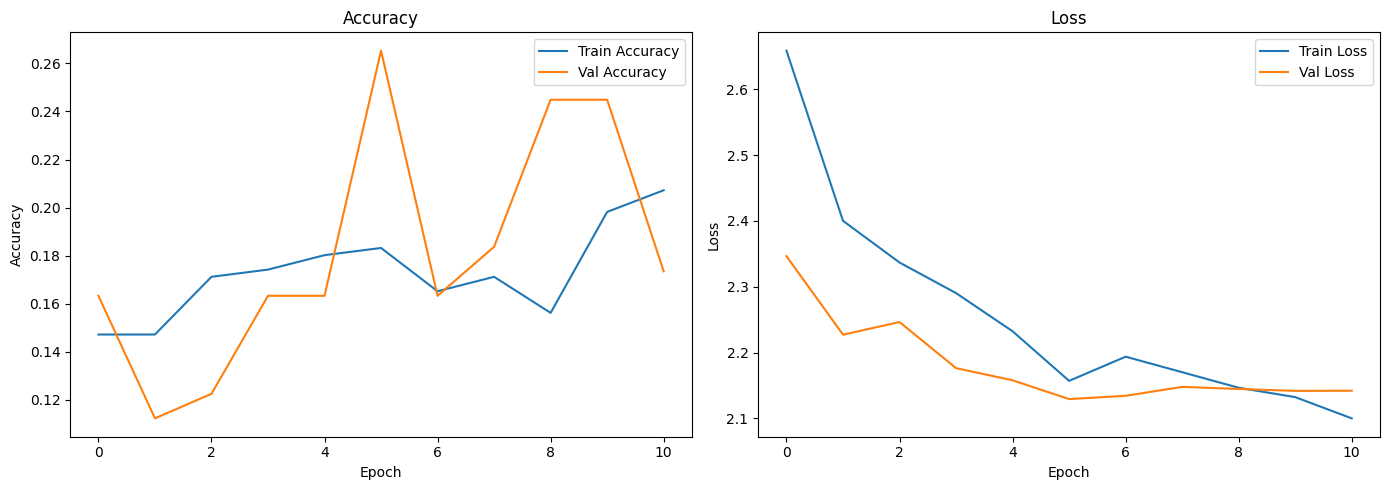

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# -------------------------------
# ⚙️ Configuration
# -------------------------------
IMG_SIZE = (224, 224)  # ResNet50 requires 224x224
BATCH_SIZE = 32
EPOCHS = 30

train_dir = 'dataset/train'
val_dir = 'dataset/val'
test_dir = 'dataset/test'
MODEL_NAME = 'activity_classifier_resnet50.h5'

# -------------------------------
# 🔁 Data Preprocessing
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

val_data = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

test_data = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=1, class_mode='categorical', shuffle=False)

NUM_CLASSES = train_data.num_classes

# -------------------------------
# 🧠 Build ResNet50 Model
# -------------------------------
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # Freeze ResNet base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# -------------------------------
# 📉 Callbacks
# -------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
    ModelCheckpoint(MODEL_NAME, save_best_only=True)
]

# -------------------------------
# 🚀 Train Model
# -------------------------------
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
)

# -------------------------------
# 💾 Save Model
# -------------------------------
model.save(MODEL_NAME)
print(f"✅ Model saved as {MODEL_NAME}")

# -------------------------------
# 📊 Evaluate on Test Data
# -------------------------------
pred_probs = model.predict(test_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

test_acc = np.mean(pred_classes == true_classes)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# 🧾 Classification Report
print("\n📄 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# 🔍 Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('🧩 Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_resnet.png')
plt.show()

# -------------------------------
# 📈 Plot Accuracy and Loss
# -------------------------------
def plot_history(hist):
    plt.figure(figsize=(14, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label='Train Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_curves_resnet.png')
    plt.show()

plot_history(history)
